In [ ]:
# https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab
# https://www.youtube.com/watch?v=WUvTyaaNkzM&list=PLZHQObOWTQDMsr9K-rj53DwVRMYO3t5Yr

# Линейная регрессия — простыми словами

## Идея

Линейная модель просто складывает входные признаки с весами и прибавляет константу:

$$
\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n
$$

Аналог на TS:
```ts
prediction = bias + w1 * x1 + w2 * x2 + ... + wn * xn
```

- `ŷ` — предсказание
- `θ₀` (bias) — константа-сдвиг
- `θ₁...θₙ` — веса признаков
- `x₁...xₙ` — сами признаки

---

## Векторная форма (то же самое, но короче)

$$
\hat{y} = \boldsymbol{\theta} \cdot \mathbf{x}
$$

Это просто **скалярное произведение** двух векторов — θ (веса модели) и x (признаки объекта). Скалярное произведение = "перемножить попарно и сложить", то есть тот же цикл `sum += w[i]*x[i]`, только записанный одним символом `·`.

Чтобы это работало, к вектору `x` спереди добавляют фиктивную единицу (`x₀ = 1`), тогда `θ₀ * 1 = θ₀` — bias "встраивается" в общую сумму.

> **Примечание книги**: если записывать θ и x как *столбцы* (стандарт в ML), то формула выглядит как `ŷ = θᵀx` — где `θᵀ` (транспонированная θ, то есть строка вместо столбца) умножается на x как матрицы. Результат тот же, просто другая запись.

---

## Как понять, насколько модель хороша

Нужна метрика ошибки. Используют **MSE** (Mean Squared Error — средняя квадратичная ошибка), потому что:
- её проще минимизировать математически, чем RMSE
- минимизация MSE даёт тот же результат, что и минимизация RMSE (это как минимизировать число или его квадратный корень — итог совпадает)

$$
\text{MSE}(\mathbf{X}, h_{\boldsymbol{\theta}}) = \frac{1}{m} \sum_{i=1}^{m} \left( \boldsymbol{\theta}^\top \mathbf{x}^{(i)} - y^{(i)} \right)^2
$$

Простыми словами:
```
для каждого объекта i:
    ошибка_i = предсказание_i - реальное_значение_i
    сложить квадраты всех ошибок
    поделить на количество объектов (m)
```

Возводим в квадрат, чтобы:
1. ошибки не "гасили" друг друга (плюс и минус)
2. штрафовать сильно за большие ошибки

⚠️ **Важно**: метрика, по которой *тренируют* модель (loss), и метрика, по которой её потом *оценивают*, часто разные — тренировочную метрику выбирают за удобство оптимизации, а не потому что она лучше всего отражает бизнес-цель.

---

## Нормальное уравнение — готовая формула для идеального θ

Хорошая новость: для линейной регрессии не нужно "подбирать" θ методом проб — есть формула, которая сразу даёт лучший результат:

$$
\hat{\boldsymbol{\theta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}
$$

Что тут происходит (по шагам):
1. `Xᵀ` — транспонировать матрицу X
2. `Xᵀ X` — умножить транспонированную X саму на себя
3. `(...)⁻¹` — найти обратную матрицу от результата
4. Всё это умножить на `Xᵀ y`

Транспонировать — это просто "повернуть" матрицу так, что строки становятся столбцами, а столбцы — строками.

Результат — вектор `θ̂`, то есть готовые веса модели, при которых MSE минимальна. Никакого обучения "шагами" не нужно — это прямое решение.

---

## Тестовый пример (код)

```python
import numpy as np
rng = np.random.default_rng(seed=42)

m = 200                                          # количество объектов
X = 2 * rng.random((m, 1))                       # признак (столбец)
y = 4 + 3 * X + rng.standard_normal((m, 1))      # цель = 4 + 3x + шум
```


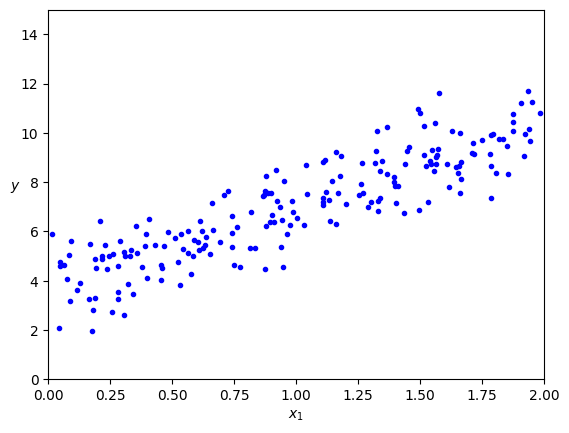

In [1]:
# Здесь искусственно генерируются данные вида
# `y ≈ 4 + 3x`, чтобы проверить: если применить 
# Normal Equation к этим данным, получится ли θ₀ ≈ 4 и θ₁ ≈ 3? 
# (Именно это книга дальше и проверяет.)
import matplotlib.pyplot as plt
import numpy as np
# фиксированный рандом
rng = np.random.default_rng(seed=42)
m = 200 # number of instances

# rng.random(...) даёт числа в диапазоне [0, 1)
# 200 строк и 1 столбец;
# Умножаем на 2 → диапазон становится [0, 2)
X = 2 * rng.random((m, 1)) # column vector,

# Это цель, то что хотим предсказать. y = 4 + 3 * x1 + шум
y = 4 + 3 * X + rng.standard_normal((m, 1)) # column vector

plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.show()

In [2]:
from sklearn.preprocessing import add_dummy_feature
# Normal Equation референс к формуле
# Про матричные умножения, стоит посмотреть html пример
# @ делает матричное умножение A @ B эквивалентно np.matmul(A, B)

# add_dummy_feature просто приписывает столбец из единиц спереди к твоей матрице X
# Так у каждого объекта появляется "фиктивный признак" x₀ = 1, который ни на что физически не влияет,
# зато делает размеры совместимыми:
# было (X):         # стало (X_b):
# [[0.5],           [[1, 0.5],
#  [1.2],           [[1, 1.2],
#  [1.8]]           [[1, 1.8]]
X_b = add_dummy_feature(X) # add x0 = 1 to each instance
# формула 𝛉 = (X⊺X)−1 X⊺ y
# inv вычислить обратную матрицу
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
print(theta_best)

# Тета0 должна была быть 4, а тета1 должна была быть 3, из-за шума чутка отличается сложно восстановить


[[3.69084138]
 [3.32960458]]


[[ 3.69084138]
 [10.35005055]]


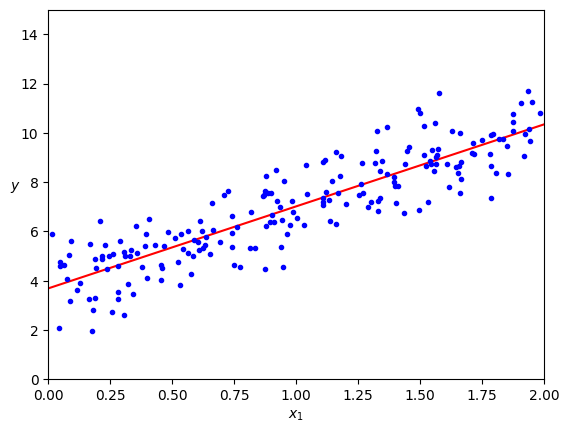

In [3]:
# теперь когда мы знаем лучшие тета, можно сделать предсказание для начального графика который
# мы разбирали 
import matplotlib.pyplot as plt
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new) # add x0 = 1 to each instance
y_predict = X_new_b @ theta_best
print(y_predict)

plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.show()


In [6]:
# Performing linear regression using scikit-learn (это намного проще)
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X,y)
print(lin_reg.intercept_,lin_reg.coef_)
print("Predict:",lin_reg.predict(X_new))

[3.69084138] [[3.32960458]]
Predict: [[ 3.69084138]
 [10.35005055]]


# Линейная регрессия через Scikit-Learn

Вместо ручного `np.linalg.inv(...)` есть готовая библиотека:

```python
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

lin_reg.intercept_, lin_reg.coef_
# (array([3.69]), array([[3.33]]))

lin_reg.predict(X_new)
# array([[3.69], [10.35]])
```

- `intercept_` — bias (θ₀)
- `coef_` — веса признаков (θ₁, θ₂...)
- Sklearn хранит их отдельно, не одним вектором θ, как мы делали руками.

---

## Что внутри `LinearRegression`

Она не считает Normal Equation напрямую (через `inv()`), а использует другой метод — **`scipy.linalg.lstsq`** ("least squares" — метод наименьших квадратов). Его тоже можно вызвать вручную:

```python
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
# theta_best_svd = [[3.69], [3.33]]  — тот же результат
```

Формула, которую он считает: **θ̂ = X⁺y**, где `X⁺` — это **псевдообратная матрица** (не обычная обратная `X⁻¹`, а её более "мягкий" аналог, называется **Moore-Penrose inverse**).

Посчитать её напрямую можно так:

```python
np.linalg.pinv(X_b) @ y
# тот же результат: [[3.69], [3.33]]
```

---

## Что такое SVD простыми словами

**SVD (singular value decomposition, сингулярное разложение)** — это способ разбить ЛЮБУЮ матрицу на произведение трёх более простых матриц. Работает всегда, в отличие от обычной обратной матрицы, которая существует не всегда — в этом весь смысл, почему sklearn использует именно SVD.

Идея похожа на разложение числа на множители (`12 = 3 × 4`), только для матриц: `X = U Σ Vᵀ`.

## Как читаются буквы

- **X** — исходная матрица (в нашем случае `X_b`, твои данные)
- **U** — читается «у» (лат.). Просто одна из трёх матриц-множителей.
- **Σ** — читается «сигма» (греческая буква). Особенная матрица: везде нули, кроме диагонали — на ней стоят так называемые "сингулярные значения" (просто набор чисел, отсортированных от большего к меньшему, показывающих "вес" каждого направления в данных).
- **V** — читается «ви» (лат.). Третья матрица-множитель.
- **Vᵀ** — читается «ви транспонированная» — V, которую перевернули (мы это разбирали раньше).
- **X⁺** — читается «икс плюс» — псевдообратная матрица от X.
- **Σ⁺** — читается «сигма плюс» — псевдообратная от Σ.

## Пример на реальных числах

```python
X_b = [[1, 0.5],
       [1, 1.2],
       [1, 1.8],
       [1, 2.0]]

U, S, Vt = np.linalg.svd(X_b, full_matrices=False)
```

```
U =
[[-0.273  0.858]
 [-0.439  0.283]
 [-0.581 -0.21 ]
 [-0.629 -0.375]]

S (сингулярные значения) = [3.534, 0.662]

Vt =
[[-0.544 -0.839]
 [ 0.839 -0.544]]
```

Если перемножить `U @ Σ @ Vᵀ` обратно — получится снова исходная `X_b`. Это как если разложил `12` на `3 × 4`, а потом перемножил обратно и получил `12`.

## Как из Σ получить Σ⁺

Σ — это просто диагональ из чисел (в примере выше: `3.534` и `0.662`). Чтобы получить `Σ⁺`:
1. все слишком маленькие числа (близкие к нулю) заменяются на 0
2. все оставшиеся (ненулевые) числа заменяются на обратные им (1/x) — например, `3.534` → `1/3.534 ≈ 0.283`
3. результат транспонируется

Псевдообратная матрица получается так: **X⁺ = V Σ⁺ Uᵀ**.

---

## Зачем это вообще нужно, если Normal Equation уже работает

Два плюса у SVD/псевдообратной матрицы перед обычным Normal Equation:

1. **Быстрее** считается на практике.
2. **Всегда работает**, даже в "сломанных" случаях. Обычная `(XᵀX)⁻¹` может не существовать (матрица «вырожденная» — не имеет обратной), например если:
   - объектов меньше, чем признаков (`m < n`)
   - какие-то признаки дублируют друг друга (избыточные, redundant)

   Псевдообратная матрица определена **всегда**, поэтому SVD — более надёжный способ, и именно его использует sklearn "под капотом".